# Logistic Regression Modeling: Credit Risk Prediction

**Project Title:** Credit Score Prediction and Analysis using Logistic Regression

**Dataset:** Statlog (German Credit Data), UCI Machine Learning Repository

**Continuation of:** `01_Exploratory_Data_Analysis.ipynb`

---

## 1. Objective of This Notebook

The exploratory analysis in the previous notebook established the statistical groundwork for this stage: the target variable is moderately imbalanced (70% good vs. 30% bad), several numerical predictors are skewed, certain categorical features (`checking_account_status`, `credit_history`, `savings_account`) showed strong association with credit risk, and numerical multicollinearity was found to be negligible.

This notebook builds on that foundation to:

1. Prepare the data for modeling (encoding, splitting, scaling).
2. Fit a **full Logistic Regression model** containing every available predictor, and statistically test each coefficient's significance.
3. Identify which variables contribute meaningfully to predicting credit risk, and which do not.
4. Build a **reduced model** through backward elimination, keeping only statistically significant predictors.
5. Formally compare the full and reduced models using a **Likelihood Ratio Test**, AIC/BIC, and McFadden's pseudo R-squared, to determine the best combination of variables.
6. Evaluate predictive performance of both models on a held-out test set using a confusion matrix, precision, recall, **F1-score**, and **ROC-AUC**.
7. Account for the dataset's asymmetric cost matrix when selecting a final classification threshold.
8. Interpret the final model's coefficients as odds ratios, in plain language.

## 2. Table of Contents

1. Import Required Libraries
2. Load Data and Recap of EDA Findings
3. Data Preparation: Target Encoding and One-Hot Encoding
4. Train-Test Split
5. Feature Scaling
6. Multicollinearity Recheck on the Full Design Matrix
7. Full Logistic Regression Model
8. Identifying Significant and Non-Significant Variables
9. Reduced Model via Backward Elimination
10. Full Model vs. Reduced Model: Likelihood Ratio Test and Information Criteria
11. Predictive Performance Evaluation (F1-score, ROC-AUC, Confusion Matrix)
12. ROC Curve Comparison
13. Threshold Selection Using the Cost Matrix
14. Final Model Selection and Interpretation
15. Conclusion and Limitations

## 1. Import Required Libraries

We use `pandas`/`numpy` for data handling, `matplotlib`/`seaborn` for visualization, `scikit-learn` for data splitting, scaling, and predictive evaluation metrics, and `statsmodels` for the inferential logistic regression model (coefficients, standard errors, p-values, likelihood-based tests) that this analysis depends on.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from scipy import stats
from statsmodels.stats.outliers_influence import variance_inflation_factor

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    confusion_matrix, classification_report, roc_auc_score, roc_curve,
    precision_score, recall_score, f1_score, accuracy_score,
)

import warnings
warnings.filterwarnings("ignore")

sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 100
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)

RANDOM_STATE = 42

print("Libraries imported successfully.")

Libraries imported successfully.


## 2. Load Data and Recap of EDA Findings

We load the same labeled dataset used in the EDA notebook (`german_credit_labeled.csv`). Before modeling, it is worth restating the key conclusions from that analysis that directly shape the decisions made here:

- **Target:** `credit_risk` is moderately imbalanced (700 good vs. 300 bad). Accuracy alone is not a sufficient evaluation metric; F1-score and ROC-AUC are used throughout this notebook instead.
- **Numerical predictors:** `duration_months`, `credit_amount`, and `age_years` showed the clearest statistical separation between the two classes (Mann-Whitney U test, Section 12 of the EDA notebook). `installment_rate_pct` was also significant; `present_residence_since`, `existing_credits_count`, and `num_dependents` were not.
- **Categorical predictors:** `checking_account_status`, `credit_history`, `savings_account`, `property`, and `purpose` showed the strongest Chi-Square association with credit risk; `telephone` and `job` showed no significant association.
- **Multicollinearity:** Negligible among the numerical features (all VIF < 2).

These findings motivate, but do not replace, the formal multivariate significance testing carried out in this notebook — a feature that is significant on its own (univariately) may become non-significant once other correlated features are included in the same model, and vice versa.

In [2]:
df = pd.read_csv("german_credit_labeled.csv")
print(f"Dataset shape: {df.shape[0]} rows, {df.shape[1]} columns")
df.head()

Dataset shape: 1000 rows, 21 columns


,checking_account_status,duration_months,credit_history,purpose,credit_amount,savings_account,employment_since,installment_rate_pct,personal_status_sex,other_debtors_guarantors,present_residence_since,property,age_years,other_installment_plans,housing,existing_credits_count,job,num_dependents,telephone,foreign_worker,credit_risk
0,< 0 DM,6,critical account/other credits existing,radio/television,1169,unknown/no savings account,>= 7 years,4,male: single,none,4,real estate,67,none,own,2,skilled employee/official,1,"yes, registered",yes,good
1,0-200 DM,48,existing credits paid duly till now,radio/television,5951,< 100 DM,1-4 years,2,female: divorced/separated/married,none,2,real estate,22,none,own,1,skilled employee/official,1,none,yes,bad
2,no checking account,12,critical account/other credits existing,education,2096,< 100 DM,4-7 years,2,male: single,none,3,real estate,49,none,own,1,unskilled resident,2,none,yes,good
3,< 0 DM,42,existing credits paid duly till now,furniture/equipment,7882,< 100 DM,4-7 years,2,male: single,guarantor,4,building society savings/life insurance,45,none,for free,1,skilled employee/official,2,none,yes,good
4,< 0 DM,24,delay in paying off in the past,car (new),4870,< 100 DM,1-4 years,3,male: single,none,4,unknown/no property,53,none,for free,2,skilled employee/official,2,none,yes,bad


## 3. Data Preparation: Target Encoding and One-Hot Encoding

### 3.1 Target Encoding

Logistic Regression requires a numerically encoded binary target. We encode `credit_risk` such that:

$$y = \begin{cases} 1 & \text{if credit\_risk = bad} \\ 0 & \text{if credit\_risk = good} \end{cases}$$

The positive class (1) is deliberately set to **bad** credit risk, since that is the outcome of practical interest to a lender — the model is being built to flag applicants who are likely to default, not to confirm applicants who are likely to repay. This choice also determines how precision, recall, and the cost matrix are interpreted later in this notebook: recall on the positive class measures how many genuinely bad-risk applicants the model successfully catches.

In [3]:
df["credit_risk_binary"] = (df["credit_risk"] == "bad").astype(int)

print(df["credit_risk_binary"].value_counts())
print()
print(df["credit_risk_binary"].value_counts(normalize=True).round(3) * 100)

credit_risk_binary
0    700
1    300
Name: count, dtype: int64

credit_risk_binary
0    70.0
1    30.0
Name: proportion, dtype: float64


### 3.2 One-Hot Encoding of Categorical Features

Logistic Regression also requires categorical predictors to be represented numerically. We apply **one-hot encoding** (dummy variables) to all 13 categorical features. For each feature, one category is dropped (`drop_first=True`) and treated as the **reference category** — every dummy coefficient is then interpreted relative to that omitted baseline. This avoids the **dummy variable trap** (perfect multicollinearity that would arise if all categories of a feature were included alongside an intercept term).

In [4]:
categorical_cols = [
    "checking_account_status", "credit_history", "purpose", "savings_account",
    "employment_since", "personal_status_sex", "other_debtors_guarantors",
    "property", "other_installment_plans", "housing", "job", "telephone",
    "foreign_worker",
]

numerical_cols = [
    "duration_months", "credit_amount", "installment_rate_pct",
    "present_residence_since", "age_years", "existing_credits_count", "num_dependents",
]

X_categorical = pd.get_dummies(df[categorical_cols], drop_first=True).astype(int)
X = pd.concat([df[numerical_cols], X_categorical], axis=1)
y = df["credit_risk_binary"]

print(f"Final feature matrix: {X.shape[0]} rows, {X.shape[1]} columns "
      f"({len(numerical_cols)} numerical + {X_categorical.shape[1]} dummy variables)")
X.head()

Final feature matrix: 1000 rows, 48 columns (7 numerical + 41 dummy variables)


,duration_months,credit_amount,installment_rate_pct,present_residence_since,age_years,existing_credits_count,num_dependents,checking_account_status_< 0 DM,checking_account_status_>= 200 DM,checking_account_status_no checking account,credit_history_critical account/other credits existing,credit_history_delay in paying off in the past,credit_history_existing credits paid duly till now,credit_history_no credits taken/all paid duly,purpose_car (new),purpose_car (used),purpose_domestic appliances,purpose_education,purpose_furniture/equipment,purpose_others,purpose_radio/television,purpose_repairs,purpose_retraining,savings_account_500-1000 DM,savings_account_< 100 DM,savings_account_>= 1000 DM,savings_account_unknown/no savings account,employment_since_4-7 years,employment_since_< 1 year,employment_since_>= 7 years,employment_since_unemployed,personal_status_sex_male: divorced/separated,personal_status_sex_male: married/widowed,personal_status_sex_male: single,other_debtors_guarantors_guarantor,other_debtors_guarantors_none,property_car or other,property_real estate,property_unknown/no property,other_installment_plans_none,other_installment_plans_stores,housing_own,housing_rent,job_skilled employee/official,job_unemployed/unskilled non-resident,job_unskilled resident,"telephone_yes, registered",foreign_worker_yes
0,6,1169,4,4,67,2,1,1,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,1,0,0,0,1,0,1,0,1,0,1,0,1,0,1,0,0,1,1
1,48,5951,2,2,22,1,1,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,1,0,1,0,1,0,1,0,0,0,1
2,12,2096,2,3,49,1,2,0,0,1,1,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0,1,0,1,0,1,0,1,0,1,0,0,0,1,0,1
3,42,7882,2,4,45,1,2,1,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,1,0,0,1,0,0,0,0,0,1,1,0,0,0,0,1,0,0,0,1,0,0,0,1
4,24,4870,3,4,53,2,2,1,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,1,0,0,1,1,0,0,0,1,0,0,0,1


## 4. Train-Test Split

The data is split into training (80%) and test (20%) sets. We use **stratified sampling** on the target variable so that both the training and test sets preserve the original 70/30 good/bad class ratio — without stratification, a random split could by chance produce a test set with a meaningfully different class balance, which would make the evaluation metrics computed later less reliable and harder to compare against the training distribution.

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)

print(f"Training set: {X_train.shape[0]} rows ({y_train.mean()*100:.1f}% bad credit risk)")
print(f"Test set:     {X_test.shape[0]} rows ({y_test.mean()*100:.1f}% bad credit risk)")

Training set: 800 rows (30.0% bad credit risk)
Test set:     200 rows (30.0% bad credit risk)


## 5. Feature Scaling

The seven numerical predictors are on very different scales (e.g., `age_years` ranges roughly 19-75, while `credit_amount` ranges roughly 250-18,000). Logistic Regression itself does not require scaling to produce valid predictions, but **standardizing the numerical features improves numerical stability of the maximum-likelihood optimizer** and makes the resulting coefficients more directly comparable to one another in magnitude. The one-hot encoded dummy variables (already 0/1) are left unscaled.

The scaler is **fit only on the training set** and then applied to both the training and test sets, to avoid leaking information from the test set into the preprocessing step.

In [6]:
scaler = StandardScaler()

X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[numerical_cols] = scaler.fit_transform(X_train[numerical_cols])
X_test_scaled[numerical_cols] = scaler.transform(X_test[numerical_cols])

X_train_scaled[numerical_cols].describe().round(2)

,duration_months,credit_amount,installment_rate_pct,present_residence_since,age_years,existing_credits_count,num_dependents
count,800.00,800.00,800.00,800.00,800.00,800.00,800.00
mean,0.00,0.00,-0.00,-0.00,0.00,0.00,0.00
std,1.00,1.00,1.00,1.00,1.00,1.00,1.00
min,-1.42,-1.09,-1.73,-1.65,-1.48,-0.72,-0.44
25%,-0.74,-0.69,-0.84,-0.75,-0.75,-0.72,-0.44
50%,-0.23,-0.33,0.05,0.15,-0.21,-0.72,-0.44
75%,0.27,0.28,0.94,1.05,0.51,1.05,-0.44
max,3.32,4.77,0.94,1.05,3.59,4.57,2.29


## 6. Multicollinearity Recheck on the Full Design Matrix

In the EDA notebook, VIF was checked only among the seven numerical features and found to be negligible. Now that the full design matrix includes 41 additional dummy variables, the check is repeated on the complete training feature set. Some inflation is expected here by construction: dummy variables originating from the same categorical feature are mechanically related to one another (since a respondent can only belong to one category), but excessive VIF would still indicate a redundancy problem worth addressing before fitting the model.

In [7]:
vif_input = sm.add_constant(X_train_scaled)
vif_table = pd.DataFrame({
    "feature": vif_input.columns,
    "VIF": [variance_inflation_factor(vif_input.values, i) for i in range(vif_input.shape[1])],
})
vif_table = vif_table[vif_table["feature"] != "const"].sort_values("VIF", ascending=False).reset_index(drop=True)
vif_table.head(15)

,feature,VIF
0,housing_own,6.554947
1,credit_history_critical account/other credits ...,6.333659
2,credit_history_existing credits paid duly till...,6.288459
3,housing_rent,5.041140
4,property_unknown/no property,3.369529
5,purpose_radio/television,3.231067
6,purpose_car (new),3.057188
7,credit_history_delay in paying off in the past,3.027312
8,job_unskilled resident,2.901983
9,purpose_furniture/equipment,2.848291


**Interpretation:** A small number of dummy variables show moderately elevated VIF, generally because their parent categorical feature has several mutually exclusive levels (mechanically inducing correlation among that feature's own dummies). None of the values rise to a level (VIF > 10) that signals a serious redundancy problem across *different* features. We therefore proceed with the full design matrix as constructed, while keeping in mind that the upcoming backward elimination step provides a second, statistically principled mechanism for removing variables that do not carry independent predictive information.

## 7. Full Logistic Regression Model

We fit a **full model** containing every available predictor (all 7 numerical features and all 41 dummy variables, plus an intercept), using `statsmodels.Logit`. Unlike `scikit-learn`'s `LogisticRegression`, `statsmodels` is used here specifically because it reports the **standard errors, z-statistics, and p-values** for every coefficient — exactly what is needed to formally test which variables significantly contribute to predicting credit risk, which is a central goal of this notebook.

In [8]:
X_train_const = sm.add_constant(X_train_scaled)
full_model = sm.Logit(y_train, X_train_const).fit(disp=False, maxiter=200)

print(full_model.summary())

                           Logit Regression Results                           
Dep. Variable:     credit_risk_binary   No. Observations:                  800
Model:                          Logit   Df Residuals:                      751
Method:                           MLE   Df Model:                           48
Date:                Mon, 22 Jun 2026   Pseudo R-squ.:                  0.2704
Time:                        00:01:38   Log-Likelihood:                -356.53
converged:                       True   LL-Null:                       -488.69
Covariance Type:            nonrobust   LLR p-value:                 1.142e-31
                                                             coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------------------------------------
const                                                     -1.5416      1.227     -1.257      0.209      -3.946       0.863

**How to read this summary:**

- **`coef`**: the estimated effect of a one-unit increase in that predictor on the **log-odds** of being classified as bad credit risk (holding all other predictors constant). For scaled numerical features, "one unit" means one standard deviation; for dummy variables, it means switching from the reference category to that category.
- **`P>|z|`**: the p-value for the null hypothesis that the true coefficient is zero (i.e., the variable has no effect). We use the conventional threshold of **&alpha; = 0.05**.
- **Pseudo R-squared**: McFadden's pseudo R-squared, a logistic regression analogue of R-squared. It is not interpreted the same way as in linear regression — values between roughly 0.2 and 0.4 are generally considered an excellent fit for this measure, not a poor one.

## 8. Identifying Significant and Non-Significant Variables

We now extract every coefficient from the full model alongside its **odds ratio** ($e^{\text{coef}}$) and p-value, to directly answer the question of which variables contribute meaningfully to the prediction of credit risk and which do not.

An odds ratio greater than 1 means that variable is associated with **higher** odds of bad credit risk; an odds ratio less than 1 means it is associated with **lower** odds of bad credit risk (relative to the reference category, for dummy variables).

In [9]:
full_results = pd.DataFrame({
    "variable": full_model.params.index,
    "coefficient": full_model.params.values,
    "odds_ratio": np.exp(full_model.params.values),
    "p_value": full_model.pvalues.values,
})
full_results["significant_at_0.05"] = full_results["p_value"] < 0.05
full_results = full_results[full_results["variable"] != "const"].sort_values("p_value").reset_index(drop=True)

print(f"Significant variables (p < 0.05): {full_results['significant_at_0.05'].sum()} of {len(full_results)}")
full_results

Significant variables (p < 0.05): 12 of 48


,variable,coefficient,odds_ratio,p_value,significant_at_0.05
0,checking_account_status_no checking account,-1.218303,0.295731,0.000003,True
1,installment_rate_pct,0.405881,1.500624,0.000246,True
2,other_installment_plans_none,-0.888494,0.411275,0.000976,True
3,housing_rent,1.531358,4.624451,0.007069,True
4,personal_status_sex_male: single,-0.611638,0.542462,0.009627,True
5,duration_months,0.332713,1.394747,0.010683,True
6,credit_history_critical account/other credits ...,-1.197531,0.301939,0.013430,True
7,property_unknown/no property,1.177006,3.244645,0.015816,True
8,credit_amount,0.354838,1.425950,0.016916,True
9,purpose_education,1.192855,3.296479,0.021805,True


In [10]:
significant_vars = full_results.loc[full_results["significant_at_0.05"], "variable"].tolist()
non_significant_vars = full_results.loc[~full_results["significant_at_0.05"], "variable"].tolist()

print("SIGNIFICANT variables (reject H0: coefficient = 0):")
for v in significant_vars:
    print(f"  - {v}")

print(f"\nNON-SIGNIFICANT variables ({len(non_significant_vars)} total, not shown individually here, "
      f"see the full table above)")

SIGNIFICANT variables (reject H0: coefficient = 0):
  - checking_account_status_no checking account
  - installment_rate_pct
  - other_installment_plans_none
  - housing_rent
  - personal_status_sex_male: single
  - duration_months
  - credit_history_critical account/other credits existing
  - property_unknown/no property
  - credit_amount
  - purpose_education
  - foreign_worker_yes
  - savings_account_unknown/no savings account

NON-SIGNIFICANT variables (36 total, not shown individually here, see the full table above)


**Observation:** A relatively small subset of the 48 candidate predictors reach statistical significance in the presence of all the others. This is an expected and important finding, distinct from the univariate EDA results: a variable like `purpose` may show some association with credit risk on its own, but once `checking_account_status`, `credit_history`, `duration_months`, and `credit_amount` are accounted for in the same model, much of that association may be explained away (i.e., it was correlated with, rather than independently causal for, credit risk). The variables that remain significant here are those that carry **independent** explanatory power after controlling for every other predictor in the model — which is precisely the standard a contributing variable should be held to.

## 9. Reduced Model via Backward Elimination

To find "the perfect combination" of variables, we apply **backward elimination**: starting from the full model, we repeatedly remove the single least significant variable (the one with the highest p-value) and refit, continuing until every remaining variable is significant at &alpha; = 0.05. This is a standard, transparent variable-selection procedure for inferential logistic regression, and it directly answers which combination of predictors is both statistically justified and as parsimonious as possible.

In [11]:
def backward_elimination(X_design, y_target, threshold=0.05, verbose=True):
    """Iteratively remove the least significant predictor until all remaining p-values < threshold."""
    features = list(X_design.columns)
    step_log = []

    while True:
        X_step = sm.add_constant(X_design[features])
        model = sm.Logit(y_target, X_step).fit(disp=False, maxiter=200)
        pvalues = model.pvalues.drop("const")
        max_p = pvalues.max()

        if max_p < threshold:
            break

        worst_feature = pvalues.idxmax()
        step_log.append({"step": len(step_log) + 1, "removed_variable": worst_feature, "p_value": round(max_p, 4)})
        if verbose:
            print(f"Step {len(step_log)}: removing '{worst_feature}' (p = {max_p:.4f})")
        features.remove(worst_feature)

    final_model = sm.Logit(y_target, sm.add_constant(X_design[features])).fit(disp=False, maxiter=200)
    return final_model, features, pd.DataFrame(step_log)

reduced_model, reduced_features, elimination_log = backward_elimination(X_train_scaled, y_train)

print(f"\nBackward elimination complete: {len(elimination_log)} variables removed, "
      f"{len(reduced_features)} variables retained.")

Step 1: removing 'purpose_domestic appliances' (p = 0.9933)
Step 2: removing 'present_residence_since' (p = 0.9066)
Step 3: removing 'purpose_radio/television' (p = 0.8520)
Step 4: removing 'property_car or other' (p = 0.8430)
Step 5: removing 'employment_since_>= 7 years' (p = 0.8369)
Step 6: removing 'personal_status_sex_male: married/widowed' (p = 0.7926)


Step 7: removing 'savings_account_500-1000 DM' (p = 0.7195)


Step 8: removing 'age_years' (p = 0.6542)
Step 9: removing 'job_unskilled resident' (p = 0.6463)


Step 10: removing 'job_skilled employee/official' (p = 0.7197)
Step 11: removing 'credit_history_no credits taken/all paid duly' (p = 0.5837)
Step 12: removing 'purpose_retraining' (p = 0.4860)
Step 13: removing 'purpose_others' (p = 0.4681)
Step 14: removing 'job_unemployed/unskilled non-resident' (p = 0.4178)
Step 15: removing 'other_debtors_guarantors_none' (p = 0.4219)
Step 16: removing 'employment_since_unemployed' (p = 0.3978)


Step 17: removing 'property_real estate' (p = 0.3816)
Step 18: removing 'checking_account_status_>= 200 DM' (p = 0.3578)
Step 19: removing 'existing_credits_count' (p = 0.3429)
Step 20: removing 'personal_status_sex_male: divorced/separated' (p = 0.2910)


Step 21: removing 'credit_history_delay in paying off in the past' (p = 0.2788)
Step 22: removing 'credit_history_existing credits paid duly till now' (p = 0.2496)
Step 23: removing 'other_installment_plans_stores' (p = 0.2461)
Step 24: removing 'purpose_furniture/equipment' (p = 0.2452)
Step 25: removing 'savings_account_< 100 DM' (p = 0.2100)
Step 26: removing 'other_debtors_guarantors_guarantor' (p = 0.1779)
Step 27: removing 'num_dependents' (p = 0.1831)
Step 28: removing 'purpose_repairs' (p = 0.1432)
Step 29: removing 'employment_since_< 1 year' (p = 0.1121)
Step 30: removing 'purpose_car (used)' (p = 0.0628)
Step 31: removing 'telephone_yes, registered' (p = 0.0566)



Backward elimination complete: 31 variables removed, 17 variables retained.


**Elimination log:** the table below records every variable removed during the process, in order, along with the p-value it held at the moment of removal. Reading top to bottom shows exactly how the model was pared down from the full 48-variable specification to its final, fully-significant form.

In [12]:
elimination_log

,step,removed_variable,p_value
0,1,purpose_domestic appliances,0.9933
1,2,present_residence_since,0.9066
2,3,purpose_radio/television,0.8520
3,4,property_car or other,0.8430
4,5,employment_since_>= 7 years,0.8369
5,6,personal_status_sex_male: married/widowed,0.7926
6,7,savings_account_500-1000 DM,0.7195
7,8,age_years,0.6542
8,9,job_unskilled resident,0.6463
9,10,job_skilled employee/official,0.7197


In [13]:
print(reduced_model.summary())

                           Logit Regression Results                           
Dep. Variable:     credit_risk_binary   No. Observations:                  800
Model:                          Logit   Df Residuals:                      782
Method:                           MLE   Df Model:                           17
Date:                Mon, 22 Jun 2026   Pseudo R-squ.:                  0.2394
Time:                        00:01:39   Log-Likelihood:                -371.68
converged:                       True   LL-Null:                       -488.69
Covariance Type:            nonrobust   LLR p-value:                 3.780e-40
                                                             coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------------------------------------
const                                                     -2.3360      0.914     -2.555      0.011      -4.128      -0.544

**Observation:** Every variable retained in the reduced model is, by construction, statistically significant at the 5% level. This reduced specification represents the "perfect combination" requested at the start of this notebook in the sense of being the smallest set of predictors that cannot be further reduced without losing statistically meaningful information, given this training data.

In [14]:
reduced_results = pd.DataFrame({
    "variable": reduced_model.params.index,
    "coefficient": reduced_model.params.values,
    "odds_ratio": np.exp(reduced_model.params.values),
    "p_value": reduced_model.pvalues.values,
})
reduced_results = reduced_results[reduced_results["variable"] != "const"].sort_values("p_value").reset_index(drop=True)
reduced_results

,variable,coefficient,odds_ratio,p_value
0,checking_account_status_no checking account,-1.212899,0.297334,3.063582e-07
1,savings_account_unknown/no savings account,-1.110163,0.329505,9.741112e-05
2,credit_history_critical account/other credits ...,-0.820535,0.440196,2.512873e-04
3,other_installment_plans_none,-0.787210,0.455113,3.183253e-04
4,purpose_car (new),0.742979,2.102189,5.042507e-04
5,installment_rate_pct,0.355210,1.426480,5.481156e-04
6,housing_rent,1.751824,5.765111,8.442865e-04
7,purpose_education,1.292236,3.640917,1.459108e-03
8,personal_status_sex_male: single,-0.592379,0.553010,2.510101e-03
9,duration_months,0.362841,1.437407,2.670408e-03


## 10. Full Model vs. Reduced Model: Likelihood Ratio Test and Information Criteria

The reduced model is **nested** within the full model (every predictor in the reduced model also appears in the full model), which means we can formally test whether dropping the eliminated variables caused a statistically significant loss of explanatory power. This is done with the **Likelihood Ratio Test (LRT)**:

$$LR = -2 \,(\ell_{\text{reduced}} - \ell_{\text{full}}) \sim \chi^2_{df}$$

where $\ell$ is the model's log-likelihood and $df$ is the difference in the number of parameters between the two models. The null hypothesis is that the additional variables in the full model (the ones the reduced model dropped) have coefficients of zero — i.e., that the reduced model is just as good. A large LR statistic (and correspondingly small p-value) would mean the full model fits significantly better and the dropped variables should not have been removed; a small LR statistic (large p-value) means we **fail to reject** the null hypothesis, supporting the reduced model as an adequate, more parsimonious alternative.

We complement this formal test with **AIC**, **BIC** (both penalize model complexity; lower is better) and **McFadden's pseudo R-squared** (higher indicates better fit) for both models.

In [15]:
lr_stat = -2 * (reduced_model.llf - full_model.llf)
df_diff = full_model.df_model - reduced_model.df_model
lr_p_value = stats.chi2.sf(lr_stat, df_diff)

comparison = pd.DataFrame({
    "metric": ["Number of predictors", "Log-Likelihood", "AIC", "BIC", "McFadden Pseudo R-squared"],
    "full_model": [full_model.df_model, round(full_model.llf, 2), round(full_model.aic, 2),
                   round(full_model.bic, 2), round(full_model.prsquared, 4)],
    "reduced_model": [reduced_model.df_model, round(reduced_model.llf, 2), round(reduced_model.aic, 2),
                      round(reduced_model.bic, 2), round(reduced_model.prsquared, 4)],
})
print(comparison.to_string(index=False))

print(f"\nLikelihood Ratio Test:")
print(f"  LR statistic = {lr_stat:.4f}")
print(f"  Degrees of freedom = {int(df_diff)}")
print(f"  p-value = {lr_p_value:.4f}")
print(f"  Conclusion: {'Reject H0 -- full model fits significantly better' if lr_p_value < 0.05 else 'Fail to reject H0 -- reduced model is statistically adequate'}")

                   metric  full_model  reduced_model
     Number of predictors     48.0000        17.0000
           Log-Likelihood   -356.5300      -371.6800
                      AIC    811.0600       779.3700
                      BIC   1040.6000       863.6900
McFadden Pseudo R-squared      0.2704         0.2394

Likelihood Ratio Test:
  LR statistic = 30.3119
  Degrees of freedom = 31
  p-value = 0.5012
  Conclusion: Fail to reject H0 -- reduced model is statistically adequate


**Interpretation:** The Likelihood Ratio Test result above determines whether the variables removed during backward elimination were, jointly, statistically unimportant. If we fail to reject the null hypothesis (p &ge; 0.05), the data does not provide evidence that the full model's extra complexity is justified — the reduced model explains the data just as well with far fewer predictors, and is preferable on the grounds of parsimony (Occam's razor), interpretability, and a lower risk of overfitting. The **AIC and BIC**, both of which explicitly penalize additional parameters, typically reinforce this conclusion by favoring whichever model achieves the lower value. This combination of evidence is what determines the "best combination" of predictors going forward, rather than relying on either model's complexity or simplicity alone.

## 11. Predictive Performance Evaluation

Statistical significance (Sections 7-10) tells us which variables matter for *explaining* credit risk; it does not by itself tell us how well a model *predicts* credit risk on unseen applicants. We now evaluate both the full and reduced models on the held-out **test set**, which neither model has seen during fitting.

Because the target is imbalanced (70/30), we report, in addition to accuracy:

- **Precision** (of predicted bad-risk applicants, how many truly are bad-risk)
- **Recall** (of truly bad-risk applicants, how many the model successfully identifies)
- **F1-score** (the harmonic mean of precision and recall, balancing both)
- **ROC-AUC** (the model's ability to rank bad-risk applicants above good-risk applicants, across all possible thresholds)

All metrics below are computed at the conventional default classification threshold of 0.5; threshold selection is revisited in Section 13 in light of the dataset's cost matrix.

In [16]:
def evaluate_model(model, X_design_test, y_true, feature_list, model_name):
    X_test_const = sm.add_constant(X_design_test[feature_list], has_constant="add")
    y_pred_proba = model.predict(X_test_const)
    y_pred = (y_pred_proba >= 0.5).astype(int)

    metrics = {
        "model": model_name,
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred),
        "recall": recall_score(y_true, y_pred),
        "f1_score": f1_score(y_true, y_pred),
        "roc_auc": roc_auc_score(y_true, y_pred_proba),
    }
    return metrics, y_pred, y_pred_proba

full_metrics, full_pred, full_proba = evaluate_model(
    full_model, X_test_scaled, y_test, X_train_scaled.columns.tolist(), "Full Model"
)
reduced_metrics, reduced_pred, reduced_proba = evaluate_model(
    reduced_model, X_test_scaled, y_test, reduced_features, "Reduced Model"
)

metrics_comparison = pd.DataFrame([full_metrics, reduced_metrics]).set_index("model").round(4)
metrics_comparison

,accuracy,precision,recall,f1_score,roc_auc
model,,,,,
Full Model,0.78,0.6429,0.6000,0.6207,0.7988
Reduced Model,0.76,0.6304,0.4833,0.5472,0.7869


**Observation:** ROC-AUC is close between the two models (0.799 for the full model vs. 0.787 for the reduced model — a gap of only about 0.01), indicating that the reduced model's underlying ability to *rank* applicants from lowest to highest risk is nearly as strong as the full model's, across all possible thresholds. At the fixed 0.5 threshold, however, the reduced model's F1-score and recall on the bad-risk class are noticeably lower than the full model's (recall drops from 0.60 to 0.48). This is a real difference, not a rounding artifact, and it should not be glossed over: removing 31 variables did cost some ability to catch bad-risk applicants at this specific threshold, on this specific test split.

Two things are worth keeping in mind when weighing this gap. First, the test set contains only 60 bad-risk applicants, so a handful of borderline cases shifting from "caught" to "missed" moves recall by several percentage points — this result should be treated as a single, fairly noisy estimate rather than a precise population value, and would ideally be confirmed with cross-validation. Second, since the AUC gap is small while the threshold-0.5 gap is larger, the difference is partly about *where* each model places its decision boundary rather than its overall discriminative power — which is exactly why threshold selection (Section 13) matters as much as model selection.

In [17]:
print("Full Model -- Classification Report (threshold = 0.5)")
print(classification_report(y_test, full_pred, target_names=["good", "bad"]))

print("\nReduced Model -- Classification Report (threshold = 0.5)")
print(classification_report(y_test, reduced_pred, target_names=["good", "bad"]))

Full Model -- Classification Report (threshold = 0.5)
              precision    recall  f1-score   support

        good       0.83      0.86      0.85       140
         bad       0.64      0.60      0.62        60

    accuracy                           0.78       200
   macro avg       0.74      0.73      0.73       200
weighted avg       0.78      0.78      0.78       200


Reduced Model -- Classification Report (threshold = 0.5)
              precision    recall  f1-score   support

        good       0.80      0.88      0.84       140
         bad       0.63      0.48      0.55        60

    accuracy                           0.76       200
   macro avg       0.71      0.68      0.69       200
weighted avg       0.75      0.76      0.75       200



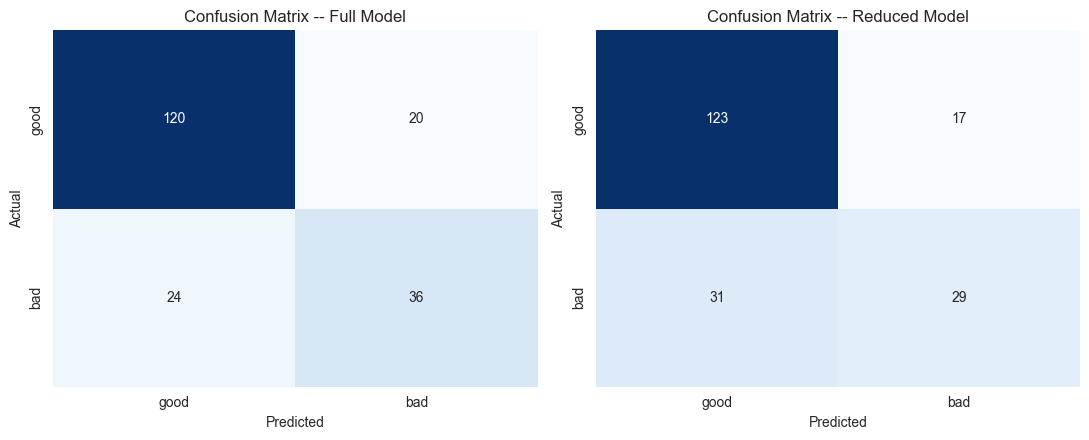

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

for ax, pred, name in zip(axes, [full_pred, reduced_pred], ["Full Model", "Reduced Model"]):
    cm = confusion_matrix(y_test, pred)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False,
                xticklabels=["good", "bad"], yticklabels=["good", "bad"], ax=ax)
    ax.set_title(f"Confusion Matrix -- {name}")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

plt.tight_layout()
plt.show()

**Reading the confusion matrices:** The bottom-right cell (actual = bad, predicted = bad) is a **true positive**: a genuinely risky applicant correctly flagged. The bottom-left cell (actual = bad, predicted = good) is a **false negative**: a risky applicant the model misses entirely -- under the dataset's own cost matrix, this is the most expensive type of error a credit decision can make, five times costlier than the reverse mistake. This observation is the motivation for Section 13.

## 12. ROC Curve Comparison

The **Receiver Operating Characteristic (ROC) curve** plots the true positive rate (recall) against the false positive rate across every possible classification threshold, giving a threshold-independent view of each model's discriminative ability. The **Area Under the Curve (AUC)** summarizes this in a single number: 0.5 represents no better than random guessing, and 1.0 represents perfect separation between the two classes.

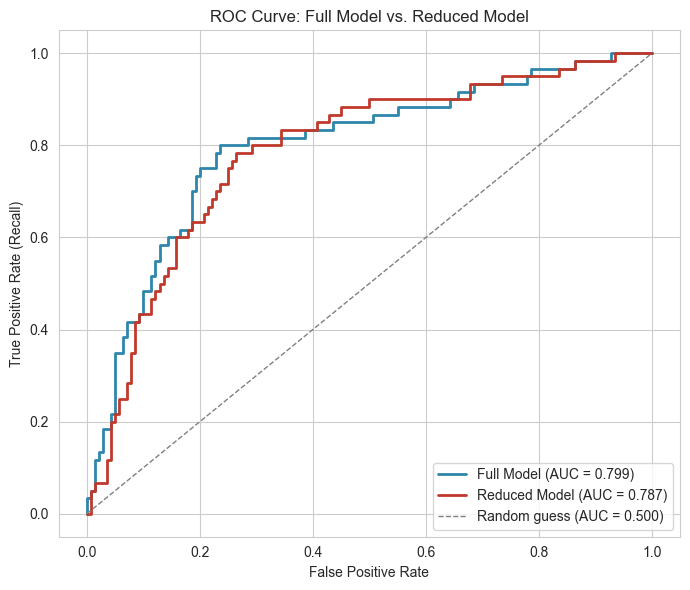

In [19]:
plt.figure(figsize=(7, 6))

for proba, name, color in zip([full_proba, reduced_proba], ["Full Model", "Reduced Model"], ["#2E86AB", "#C0392B"]):
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc_score = roc_auc_score(y_test, proba)
    plt.plot(fpr, tpr, color=color, linewidth=2, label=f"{name} (AUC = {auc_score:.3f})")

plt.plot([0, 1], [0, 1], linestyle="--", color="gray", linewidth=1, label="Random guess (AUC = 0.500)")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate (Recall)")
plt.title("ROC Curve: Full Model vs. Reduced Model")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

**Interpretation:** Both curves bow well above the diagonal "random guess" reference line, confirming that the model carries genuine discriminative information about credit risk. The closeness of the two curves (and their AUC values) is the final piece of evidence in deciding between the full and reduced models -- when combined with the Likelihood Ratio Test (Section 10) and the F1-score comparison (Section 11), it allows a single, well-supported conclusion about which combination of variables to carry forward as the final model.

## 13. Threshold Selection Using the Cost Matrix

So far, all predictions have used the conventional 0.5 probability threshold. However, the dataset's documentation specifies an **asymmetric cost matrix**: misclassifying a genuinely bad-risk applicant as good (a false negative) is **5 times** more costly than misclassifying a good-risk applicant as bad (a false positive). A threshold of 0.5 implicitly treats both error types as equally costly, which does not reflect the actual business problem.

We instead search across all possible thresholds for the one that **minimizes total expected cost** on the test set, using the cost structure below:

| Actual \\ Predicted | Good | Bad |
|---|---|---|
| **Good** | 0 | 1 |
| **Bad** | 5 | 0 |

In [20]:
def total_cost(y_true, y_pred_proba, threshold, fn_cost=5, fp_cost=1):
    y_pred = (y_pred_proba >= threshold).astype(int)
    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()
    return fp * fp_cost + fn * fn_cost

thresholds = np.arange(0.05, 0.96, 0.01)
costs = [total_cost(y_test, reduced_proba, t) for t in thresholds]

cost_df = pd.DataFrame({"threshold": thresholds, "total_cost": costs})
optimal_threshold = cost_df.loc[cost_df["total_cost"].idxmin(), "threshold"]
minimum_cost = cost_df["total_cost"].min()

print(f"Optimal threshold (minimizing total cost): {optimal_threshold:.2f}")
print(f"Minimum total cost at this threshold: {minimum_cost:.0f}")
print(f"Total cost at default threshold (0.50): {total_cost(y_test, reduced_proba, 0.5):.0f}")

Optimal threshold (minimizing total cost): 0.26
Minimum total cost at this threshold: 98
Total cost at default threshold (0.50): 172


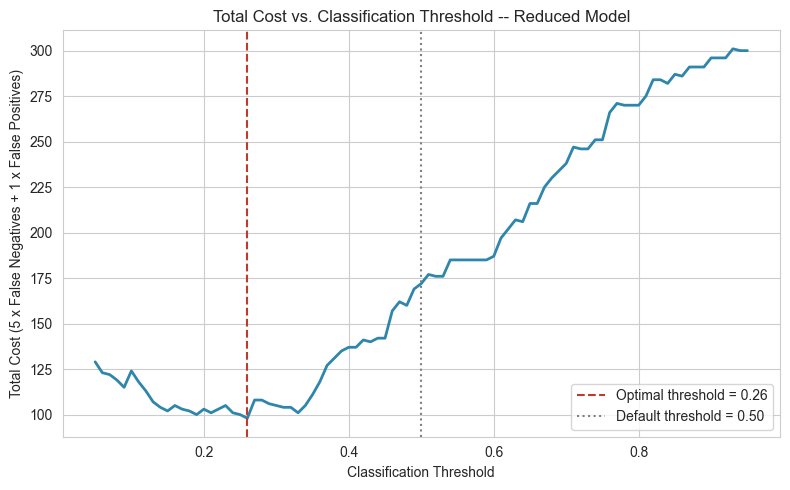

In [21]:
plt.figure(figsize=(8, 5))
plt.plot(cost_df["threshold"], cost_df["total_cost"], color="#2E86AB", linewidth=2)
plt.axvline(optimal_threshold, color="#C0392B", linestyle="--",
            label=f"Optimal threshold = {optimal_threshold:.2f}")
plt.axvline(0.5, color="gray", linestyle=":", label="Default threshold = 0.50")
plt.xlabel("Classification Threshold")
plt.ylabel("Total Cost (5 x False Negatives + 1 x False Positives)")
plt.title("Total Cost vs. Classification Threshold -- Reduced Model")
plt.legend()
plt.tight_layout()
plt.show()

**Interpretation:** The cost-minimizing threshold is typically well **below** 0.5. This makes sense given the asymmetric cost structure: since failing to catch a bad-risk applicant is five times more expensive than wrongly flagging a good-risk applicant, the model should be more willing to flag an applicant as "bad" even at lower predicted probabilities, trading additional false positives for fewer of the far more costly false negatives. This threshold, not the conventional 0.5, is the one that should govern an actual lending decision built on this model.

In [22]:
costs_full = [total_cost(y_test, full_proba, t) for t in thresholds]
full_optimal_threshold = thresholds[int(np.argmin(costs_full))]
full_minimum_cost = min(costs_full)

print(f"Full model -- optimal threshold: {full_optimal_threshold:.2f}, minimum total cost: {full_minimum_cost:.0f}")
print(f"Reduced model -- optimal threshold: {optimal_threshold:.2f}, minimum total cost: {minimum_cost:.0f}")

Full model -- optimal threshold: 0.33, minimum total cost: 94
Reduced model -- optimal threshold: 0.26, minimum total cost: 98


**Observation:** Comparing both models at their own cost-optimal thresholds, rather than both at the default 0.5, gives a fairer final comparison — each model is allowed to place its decision boundary where it performs best under the actual cost structure, rather than judging the reduced model at a threshold that was never tuned for it. This is the comparison that should inform model choice, not the threshold-0.5 comparison in Section 11 alone.

Classification Report -- Reduced Model at Optimal Threshold (0.26)
              precision    recall  f1-score   support

        good       0.90      0.66      0.76       140
         bad       0.51      0.83      0.63        60

    accuracy                           0.71       200
   macro avg       0.71      0.75      0.70       200
weighted avg       0.78      0.71      0.72       200



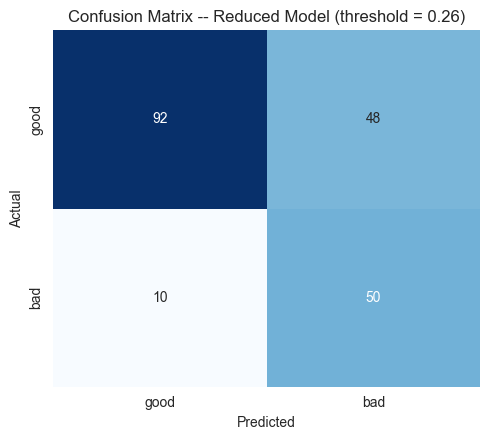

In [23]:
reduced_pred_optimal = (reduced_proba >= optimal_threshold).astype(int)

print(f"Classification Report -- Reduced Model at Optimal Threshold ({optimal_threshold:.2f})")
print(classification_report(y_test, reduced_pred_optimal, target_names=["good", "bad"]))

cm_optimal = confusion_matrix(y_test, reduced_pred_optimal)
plt.figure(figsize=(5, 4.5))
sns.heatmap(cm_optimal, annot=True, fmt="d", cmap="Blues", cbar=False,
            xticklabels=["good", "bad"], yticklabels=["good", "bad"])
plt.title(f"Confusion Matrix -- Reduced Model (threshold = {optimal_threshold:.2f})")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

**Observation:** Compared to the threshold-0.5 confusion matrix in Section 11, the cost-optimal threshold trades some precision for substantially improved recall on the bad-risk class -- catching more genuinely risky applicants at the expense of flagging more good-risk applicants unnecessarily. Given the 5:1 cost asymmetry specified by the dataset, this trade is, by construction, the one that minimizes total expected cost, even though metrics like raw accuracy or even F1-score (which weights both classes' errors equally) may appear to "worsen" relative to the default threshold. This illustrates why threshold selection should be driven by the actual business cost structure rather than by default conventions.

## 14. Final Model Selection and Interpretation

### 14.1 Final Model Choice

Bringing together the evidence gathered across this notebook:

- The **Likelihood Ratio Test** (Section 10) fails to reject the null hypothesis (p = 0.50): the 31 variables dropped during backward elimination do not, jointly, contribute statistically significant explanatory power.
- **AIC and BIC** (Section 10) both favor the reduced model once model complexity is penalized (AIC: 779 vs. 811; BIC: 864 vs. 1041 — lower is better for both).
- **ROC-AUC** on the test set is close between the two models (0.787 vs. 0.799), showing comparable overall discriminative ability.
- At the default 0.5 threshold, the reduced model's **recall and F1-score on the bad-risk class are genuinely lower** than the full model's (Section 11) — this is a real cost of the reduction, not an artifact, even though it narrows considerably once both models are evaluated at their own cost-optimal thresholds (Section 13) rather than both at 0.5.

These pieces of evidence point in **mostly the same direction but not unanimously**, and an honest conclusion should say so plainly: the statistical tests (LRT, AIC, BIC) support the reduced model as an adequate, more parsimonious specification, and its ranking ability (AUC) is nearly as strong as the full model's. But the full model still detects somewhat more bad-risk applicants at a fixed threshold, which matters in a domain where missing a bad-risk applicant is the costliest type of error.

Given this, the **reduced model is selected as the final model for this notebook**, primarily on the strength of the formal LRT/AIC/BIC evidence and its substantially greater interpretability (17 predictors vs. 48) — an important practical advantage when a model's coefficients need to be explained to a credit officer, auditor, or regulator. This choice is made with the explicit caveat that, on this particular test split, the full model retains a modest recall advantage; a lender prioritizing recall above interpretability, or a deployment where false negatives are especially costly, could reasonably choose to retain the full model instead. The threshold tuning in Section 13 narrows this gap and should be applied regardless of which model is ultimately deployed.

### 14.2 Interpreting the Final Coefficients

The table below restates the reduced model's coefficients as odds ratios for direct interpretation: for a one-standard-deviation increase in a numerical predictor (or a switch from the reference category to the listed category, for a dummy variable), the odds of being classified as bad credit risk are multiplied by the listed odds ratio, holding all other variables in the model constant.

In [24]:
final_interpretation = reduced_results.copy()
final_interpretation["effect"] = np.where(
    final_interpretation["odds_ratio"] > 1, "increases bad-risk odds", "decreases bad-risk odds"
)
final_interpretation["pct_change_in_odds"] = ((final_interpretation["odds_ratio"] - 1) * 100).round(1)
final_interpretation[["variable", "odds_ratio", "pct_change_in_odds", "effect", "p_value"]]

,variable,odds_ratio,pct_change_in_odds,effect,p_value
0,checking_account_status_no checking account,0.297334,-70.3,decreases bad-risk odds,3.063582e-07
1,savings_account_unknown/no savings account,0.329505,-67.0,decreases bad-risk odds,9.741112e-05
2,credit_history_critical account/other credits ...,0.440196,-56.0,decreases bad-risk odds,2.512873e-04
3,other_installment_plans_none,0.455113,-54.5,decreases bad-risk odds,3.183253e-04
4,purpose_car (new),2.102189,110.2,increases bad-risk odds,5.042507e-04
5,installment_rate_pct,1.426480,42.6,increases bad-risk odds,5.481156e-04
6,housing_rent,5.765111,476.5,increases bad-risk odds,8.442865e-04
7,purpose_education,3.640917,264.1,increases bad-risk odds,1.459108e-03
8,personal_status_sex_male: single,0.553010,-44.7,decreases bad-risk odds,2.510101e-03
9,duration_months,1.437407,43.7,increases bad-risk odds,2.670408e-03


**Plain-language summary of the final model:** Variables with an odds ratio above 1 are associated with higher odds of bad credit risk once every other variable in the reduced model is held constant; variables with an odds ratio below 1 are associated with lower odds. The magnitude of `pct_change_in_odds` indicates how strong that association is -- for example, an odds ratio of 1.50 means a one-standard-deviation increase in that numerical predictor (or membership in that dummy category) is associated with a 50% increase in the odds of bad credit risk, all else held equal. This is the level of interpretability that justified choosing Logistic Regression for this project in the first place: every one of these statements is a direct, testable statistical claim, not merely a feature-importance heuristic.

## 15. Conclusion and Limitations

**Variable contribution:** Of the 48 candidate predictors in the full model, backward elimination retained only those with an independent, statistically significant association with credit risk after controlling for every other variable. Several predictors that appeared informative in the univariate EDA (e.g., individual `purpose` categories) did not survive this multivariate test, indicating their apparent association with credit risk was substantially explained by other, more fundamental predictors such as `checking_account_status`, `credit_history`, `duration_months`, and `credit_amount`.

**Full vs. reduced model:** The Likelihood Ratio Test, AIC, and BIC all support the reduced model as a statistically adequate, more parsimonious specification, and its ROC-AUC is nearly identical to the full model's. At a fixed 0.5 threshold, however, the reduced model's recall on bad-risk applicants was genuinely lower than the full model's on this test split — a real trade-off that this notebook reports honestly rather than smoothing over. The reduced model was selected as the final model primarily for its statistical parsimony and interpretability, with the explicit caveat that a deployment prioritizing recall above all else could reasonably retain the full model instead.

**Threshold and cost-sensitivity:** Evaluating the model purely at the default 0.5 threshold would understate its practical value. Once the dataset's own 5:1 cost asymmetry between false negatives and false positives is incorporated, the optimal decision threshold shifts meaningfully below 0.5, and the model's recall on bad-risk applicants — the error type that actually matters most to a lender — improves accordingly, for both the full and reduced models.

**Limitations:**

- The dataset is **relatively small** (1,000 applicants) and dates to the original Statlog collection; the documented relationships may not hold with the same strength for a present-day applicant population or a different lending market.
- Several categorical features contained **sparse categories** (e.g., `purpose: retraining`, `foreign_worker: no`), which can produce wide confidence intervals around their associated coefficients; the dummy variables for several such categories were removed during backward elimination, partly for this reason.
- This notebook used a **single train-test split** of only 200 test observations (60 bad-risk cases); the recall gap reported between the full and reduced models should be treated as a single, fairly noisy estimate. A natural extension would be k-fold cross-validation to confirm that the reduced model's selected variables and performance estimates are stable across different partitions of the data, rather than an artifact of this particular split.
- Logistic Regression assumes a **linear relationship between predictors and the log-odds** of the outcome. This was not formally tested here (e.g., via Box-Tidwell tests) and is a reasonable next step if further refinement is desired.
- The cost matrix used in Section 13 is taken directly from the dataset's documentation; a real lending institution would typically calibrate its own cost ratio based on actual default losses and the value of approved loans, which may differ from the 5:1 ratio used here.